# Case II - Wearable Biosignal Representation

This notebook contains the complete analysis pipeline for **Case II in 02582 Computational Data Analysis**.

The main question is:

> Can low-dimensional representations of wearable biosignals reveal experimental and emotional states, or are the patterns mainly dominated by individual physiological baselines?

The analysis follows the required project logic:

1. **Data preprocessing**: missing values, feature groups, scaling, and factor handling.
2. **Representation**: PCA as the main transparent low-dimensional representation.
3. **Evaluation**: phase-alignment diagnostics, CCA for emotion association, and subject-aware validation using `Individual` groups.



## 1. Imports and project paths

This cell defines the project folders and checks that the local data file exists.

The dataset itself should be kept locally in the `data/` folder. The notebook saves generated figures to `figures/` and numerical tables to `results/`.

In [1]:
from __future__ import annotations

import os

# Keep linear algebra libraries from overusing threads on this small dataset.
# These environment variables should be set before importing NumPy / scikit-learn.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import json
import warnings
from pathlib import Path

# Suppress local environment warnings that may appear on some Mac/Anaconda setups.
# These warnings do not change the numerical results, but they make the notebook output noisy.
warnings.filterwarnings(
    "ignore",
    message=r"\s*Found Intel OpenMP.*",
    category=RuntimeWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r".*KMeans.*memory leak.*",
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import GroupKFold, KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Project folders. Run the notebook from the project root folder.
PROJECT_ROOT = Path.cwd()

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "HR_data.csv",
    PROJECT_ROOT / "HR_data.csv",
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    DATA_CANDIDATES[0],
)

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Could not find HR_data.csv. Place it either in the project root folder "
        "or in a data/ folder as data/HR_data.csv before running this notebook."
    )

shown_path = DATA_PATH.relative_to(PROJECT_ROOT)

print("Project folders are ready.")
print("Using local dataset file:", shown_path)


Project folders are ready.
Using local dataset file: data/HR_data.csv


## 2. Column definitions

The columns are separated into metadata, physiological features, and questionnaire variables. Metadata is not used as physiological input, but it is important for coloring plots and for subject-aware validation.

In [2]:
METADATA_COLS = ["Unnamed: 0", "Round", "Phase", "Individual", "Puzzler", "Cohort"]

EMOTION_COLS = [
    "Frustrated", "upset", "hostile", "alert", "ashamed", "inspired",
    "nervous", "attentive", "afraid", "active", "determined",
]

POSITIVE_COLS = ["active", "alert", "attentive", "determined", "inspired"]
NEGATIVE_COLS = ["afraid", "ashamed", "hostile", "nervous", "upset"]
FACTOR_COLS = ["Individual", "Phase", "Round", "Puzzler", "Cohort"]

PHASE_MAP = {
    "phase1": "Pre-puzzle/rest",
    "phase2": "Puzzle/stress",
    "phase3": "Post-puzzle/recovery",
}

## 3. Helper functions



- `eta_squared` measures how much a categorical factor is associated with a numerical questionnaire variable.
- `cca_cross_validation` evaluates CCA using either random folds or subject-aware folds.

In [3]:
def eta_squared(category: pd.Series, values: pd.Series) -> float:
    """Compute eta-squared between a categorical factor and a numerical variable."""
    data = pd.DataFrame({"category": category, "value": values}).dropna()
    if data.empty:
        return np.nan

    grand_mean = data["value"].mean()
    ss_between = sum(
        len(group) * (group["value"].mean() - grand_mean) ** 2
        for _, group in data.groupby("category")
    )
    ss_total = ((data["value"] - grand_mean) ** 2).sum()
    return float(ss_between / ss_total) if ss_total > 0 else np.nan


def cca_cross_validation(
    X: pd.DataFrame,
    Y: pd.DataFrame,
    groups: np.ndarray,
    grouped: bool,
    n_splits: int = 5,
) -> np.ndarray:
    """Evaluate one-component CCA using random CV or subject-aware GroupKFold."""
    if grouped:
        splits = GroupKFold(n_splits=n_splits).split(X, Y, groups=groups)
    else:
        splits = KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, Y)

    fold_corrs = []

    for train_idx, test_idx in splits:
        # Fit all preprocessing only on the training fold to avoid leakage.
        x_imputer = SimpleImputer(strategy="median").fit(X.iloc[train_idx])
        X_train = x_imputer.transform(X.iloc[train_idx])
        X_test = x_imputer.transform(X.iloc[test_idx])

        x_scaler = StandardScaler().fit(X_train)
        X_train = x_scaler.transform(X_train)
        X_test = x_scaler.transform(X_test)

        y_imputer = SimpleImputer(strategy="median").fit(Y.iloc[train_idx])
        Y_train = y_imputer.transform(Y.iloc[train_idx])
        Y_test = y_imputer.transform(Y.iloc[test_idx])

        y_scaler = StandardScaler().fit(Y_train)
        Y_train = y_scaler.transform(Y_train)
        Y_test = y_scaler.transform(Y_test)

        cca = CCA(n_components=1, max_iter=500, tol=1e-4)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            cca.fit(X_train, Y_train)
            X_score, Y_score = cca.transform(X_test, Y_test)

        if np.std(X_score[:, 0]) < 1e-8 or np.std(Y_score[:, 0]) < 1e-8:
            fold_corrs.append(np.nan)
        else:
            fold_corrs.append(float(np.corrcoef(X_score[:, 0], Y_score[:, 0])[0, 1]))

    return np.array(fold_corrs, dtype=float)

## 4. Load data and create basic overview

This section reads the extracted feature file and checks the main dimensions of the dataset.

In [4]:
df = pd.read_csv(DATA_PATH)
df["Phase_label"] = df["Phase"].map(PHASE_MAP).fillna(df["Phase"])

# Physiological features are all columns that are not metadata or questionnaire columns.
feature_cols = [col for col in df.columns if col not in METADATA_COLS + EMOTION_COLS + ["Phase_label"]]
X = df[feature_cols]
groups = df["Individual"].to_numpy()
phase_encoded = LabelEncoder().fit_transform(df["Phase"])

overview = {
    "n_rows": int(df.shape[0]),
    "n_columns": int(df.shape[1] - 1),  # subtract helper column Phase_label
    "n_individuals": int(df["Individual"].nunique()),
    "n_phases": int(df["Phase"].nunique()),
    "n_rounds": int(df["Round"].nunique()),
    "n_physio_features": len(feature_cols),
    "n_emotion_variables": len(EMOTION_COLS),
}

overview_df = pd.DataFrame([overview])
overview_df.to_csv(RESULTS_DIR / "dataset_overview.csv", index=False)
overview_df

,n_rows,n_columns,n_individuals,n_phases,n_rounds,n_physio_features,n_emotion_variables
0,312,68,26,3,4,51,11


## 5. Missing values and emotion summaries

 Here we save both the missing-value counts and descriptive statistics for the questionnaire variables.

In [5]:
missing_values = df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
missing_values.to_csv(RESULTS_DIR / "missing_values.csv", header=["missing_count"])

emotion_stats = df[EMOTION_COLS].describe().T[["mean", "std", "min", "max"]]
emotion_stats.to_csv(RESULTS_DIR / "emotion_descriptive_statistics.csv")

print("Total missing entries:", int(df.isna().sum().sum()))
display(missing_values.to_frame("missing_count"))
display(emotion_stats)

Total missing entries: 9


,missing_count
inspired,2
determined,2
EDA_TD_P_RT,1
EDA_TD_P_ReT,1
attentive,1
afraid,1
active,1


,mean,std,min,max
Frustrated,2.022436,1.986160,0.0,8.0
upset,1.346154,0.617576,1.0,4.0
hostile,1.057692,0.271719,1.0,3.0
alert,2.192308,1.037034,1.0,5.0
ashamed,1.221154,0.549014,1.0,4.0
inspired,2.183871,1.027958,1.0,5.0
nervous,1.381410,0.577199,1.0,3.0
attentive,2.784566,1.113793,1.0,5.0
afraid,1.051447,0.273430,1.0,4.0
active,2.553055,1.173463,1.0,5.0


## 6. Exploratory emotion plots

These plots describe the questionnaire side of the data. They are useful for explaining why positive and negative emotions may behave differently.

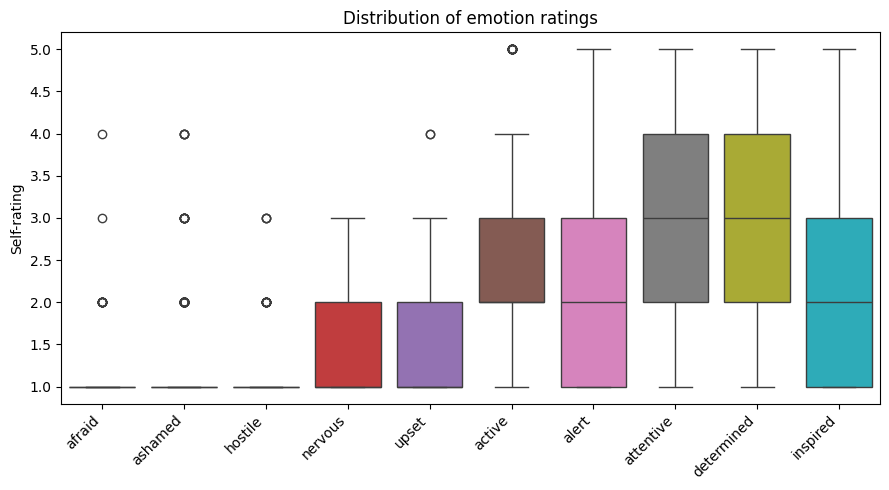

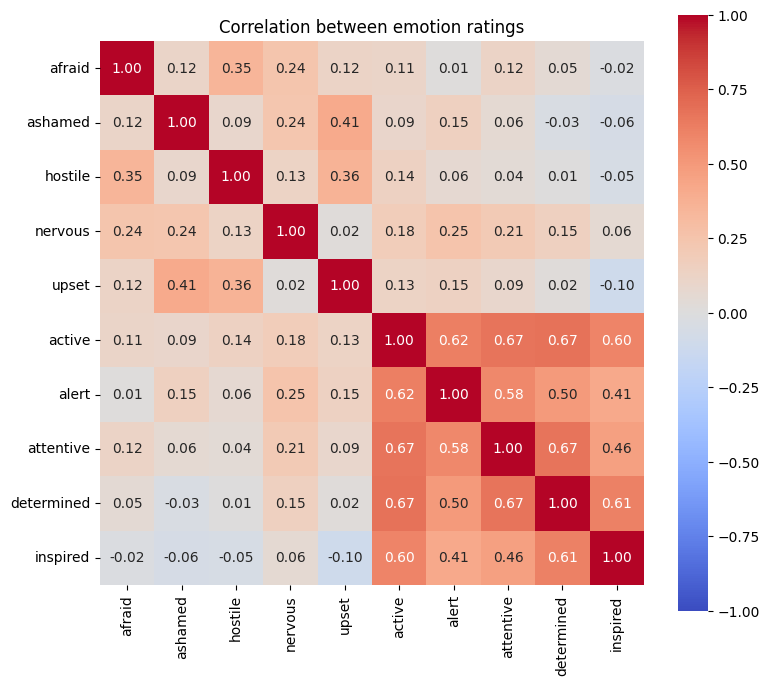

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[NEGATIVE_COLS + POSITIVE_COLS], orient="v")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Self-rating")
plt.title("Distribution of emotion ratings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "emotion_boxplot.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 7))
sns.heatmap(
    df[NEGATIVE_COLS + POSITIVE_COLS].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Correlation between emotion ratings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "emotion_correlation_heatmap.png", dpi=250)
plt.show()

## 7. PCA representation

PCA is used as the main transparent representation method. The input features are imputed and standardized before PCA because the physiological variables have different units and scales.

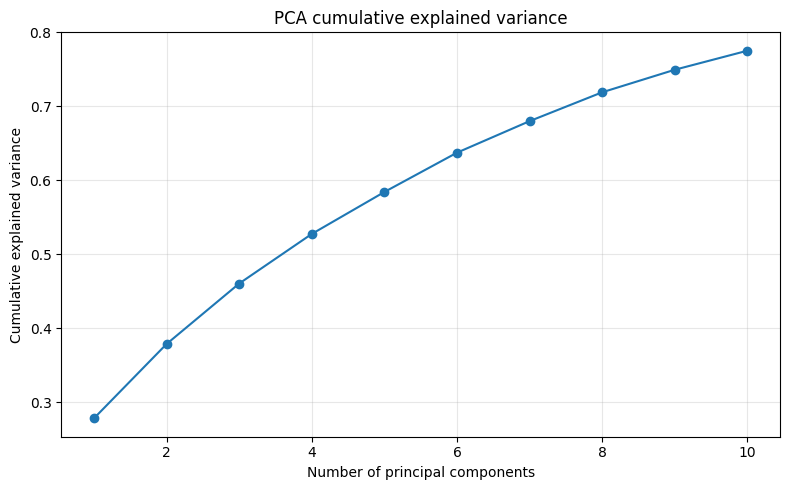

,component,explained_variance_ratio,cumulative
0,PC1,0.278102,0.278102
1,PC2,0.100482,0.378585
2,PC3,0.081761,0.460345
3,PC4,0.067080,0.527425
4,PC5,0.056729,0.584154
5,PC6,0.053156,0.637310
6,PC7,0.042658,0.679968
7,PC8,0.039014,0.718982
8,PC9,0.030482,0.749464
9,PC10,0.025755,0.775219


In [7]:
X_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X))

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_table = pd.DataFrame(
    {
        "component": [f"PC{i + 1}" for i in range(10)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative": np.cumsum(pca.explained_variance_ratio_),
    }
)
pca_table.to_csv(RESULTS_DIR / "pca_explained_variance.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 11), np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_explained_variance.png", dpi=250)
plt.show()

pca_table

## 8. PCA plots by phase and individual

The same PCA representation is visualized twice: once by experimental phase and once by individual. This directly tests whether the geometry is more phase-related or subject-related.

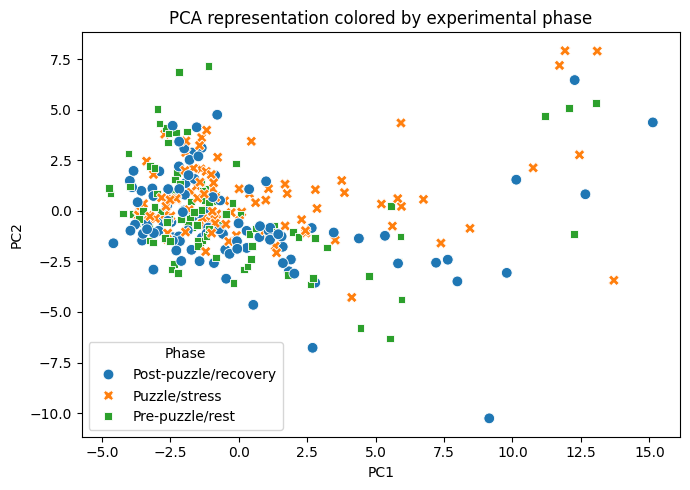

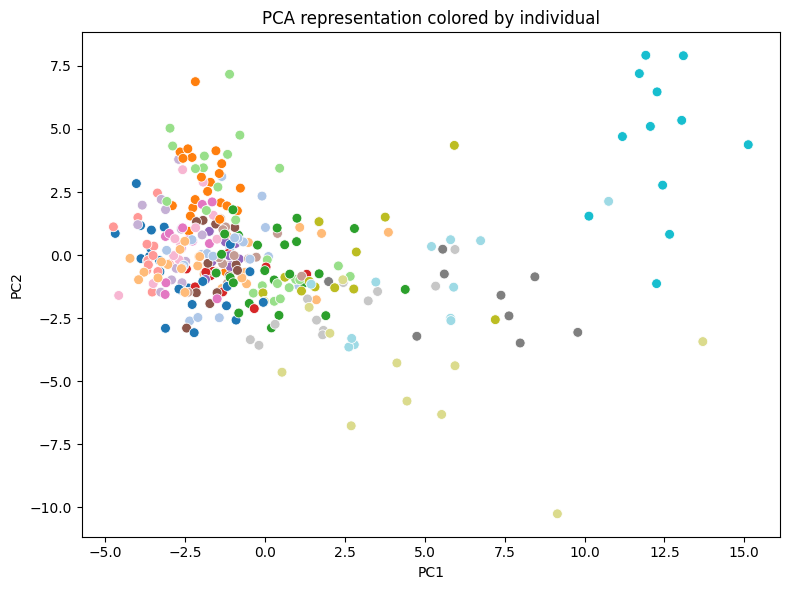

In [8]:
pca_plot_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "Phase": df["Phase_label"],
        "Individual": df["Individual"],
    }
)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="Phase", style="Phase", s=60)
plt.title("PCA representation colored by experimental phase")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_by_phase.png", dpi=250)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Individual",
    palette="tab20",
    s=50,
    legend=False,
)
plt.title("PCA representation colored by individual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_by_individual.png", dpi=250)
plt.show()

## 9. PCA loadings

The loadings help interpret which physiological features contribute most to the first principal component.

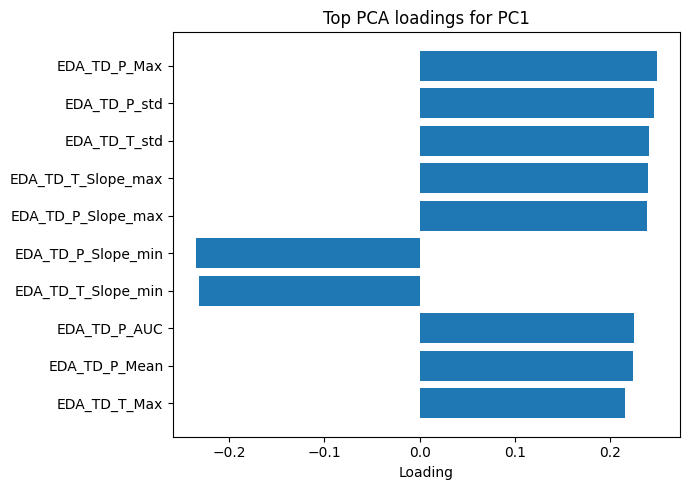

,PC1,PC2,abs_PC1,abs_PC2
EDA_TD_P_Max,0.248977,0.049867,0.248977,0.049867
EDA_TD_P_std,0.245851,0.053624,0.245851,0.053624
EDA_TD_T_std,0.240991,0.011094,0.240991,0.011094
EDA_TD_T_Slope_max,0.239388,0.025345,0.239388,0.025345
EDA_TD_P_Slope_max,0.238591,0.054842,0.238591,0.054842
EDA_TD_P_Slope_min,-0.234531,-0.051470,0.234531,0.051470
EDA_TD_T_Slope_min,-0.231921,-0.023935,0.231921,0.023935
EDA_TD_P_AUC,0.224926,0.153305,0.224926,0.153305
EDA_TD_P_Mean,0.223961,0.154965,0.223961,0.154965
EDA_TD_T_Max,0.215027,-0.164743,0.215027,0.164743


In [9]:
loadings = pd.DataFrame(pca.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()
loadings.to_csv(RESULTS_DIR / "pca_loadings.csv")

top_pc1 = loadings.sort_values("abs_PC1", ascending=False).head(10).iloc[::-1]
plt.figure(figsize=(7, 5))
plt.barh(top_pc1.index, top_pc1["PC1"])
plt.title("Top PCA loadings for PC1")
plt.xlabel("Loading")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_top_loadings_pc1.png", dpi=250)
plt.show()

display(loadings.sort_values("abs_PC1", ascending=False).head(10))

## 10. Unsupervised phase-alignment diagnostic

K-means with `K=3` is applied to the first five PCA scores. This is not optimized using labels. It is only a diagnostic: if the dominant unsupervised structure matches the experimental phases, the adjusted Rand index should be clearly above zero.

In [10]:
pca_clusters = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20,
    algorithm="lloyd",
).fit_predict(X_pca[:, :5])

cluster_results = pd.DataFrame(
    {
        "embedding": ["PCA first 5 components"],
        "ARI_vs_Phase": [adjusted_rand_score(phase_encoded, pca_clusters)],
        "silhouette": [silhouette_score(X_pca[:, :5], pca_clusters)],
    }
)

cluster_results.to_csv(RESULTS_DIR / "clustering_phase_alignment.csv", index=False)
cluster_results

,embedding,ARI_vs_Phase,silhouette
0,PCA first 5 components,-0.002461,0.329117


## 11. Phase diagnostic validation

A simple phase classifier is used only as a diagnostic for whether the representation carries phase information. The important comparison is random validation versus subject-aware validation using `Individual` groups.

In [11]:
phase_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=5, random_state=42)),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ]
)

random_scores = cross_val_score(
    phase_pipe,
    X,
    phase_encoded,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
)

group_scores = cross_val_score(
    phase_pipe,
    X,
    phase_encoded,
    cv=GroupKFold(n_splits=5),
    groups=groups,
    scoring="balanced_accuracy",
)

phase_validation = pd.DataFrame(
    {
        "validation": ["Random Stratified 5-fold", "Subject-aware GroupKFold"],
        "mean_balanced_accuracy": [random_scores.mean(), group_scores.mean()],
        "std_balanced_accuracy": [random_scores.std(), group_scores.std()],
        "fold_scores": [
            ", ".join(f"{score:.3f}" for score in random_scores),
            ", ".join(f"{score:.3f}" for score in group_scores),
        ],
    }
)
phase_validation.to_csv(RESULTS_DIR / "phase_classification_validation.csv", index=False)
phase_validation

,validation,mean_balanced_accuracy,std_balanced_accuracy,fold_scores
0,Random Stratified 5-fold,0.459048,0.039780,"0.476, 0.381, 0.466, 0.488, 0.484"
1,Subject-aware GroupKFold,0.458333,0.057735,"0.542, 0.483, 0.467, 0.433, 0.367"


## 12. CCA validation

CCA is used as a supplementary analysis linking physiological features to questionnaire variables. The full-data CCA is only for interpretation; the validation table is the safer estimate of generalization.

In [12]:
cca_rows = []

for name, cols in [
    ("Positive emotions", POSITIVE_COLS),
    ("Negative emotions", NEGATIVE_COLS),
    ("All emotions incl. frustration", EMOTION_COLS),
]:
    for grouped in [False, True]:
        corrs = cca_cross_validation(X, df[cols], groups, grouped=grouped)
        cca_rows.append(
            {
                "emotion_set": name,
                "validation": "Subject-aware GroupKFold" if grouped else "Random 5-fold",
                "mean_canonical_corr": np.nanmean(corrs),
                "std_canonical_corr": np.nanstd(corrs),
                "fold_scores": ", ".join(f"{corr:.3f}" for corr in corrs),
            }
        )

cca_results = pd.DataFrame(cca_rows)
cca_results.to_csv(RESULTS_DIR / "cca_validation_results.csv", index=False)
cca_results

,emotion_set,validation,mean_canonical_corr,std_canonical_corr,fold_scores
0,Positive emotions,Random 5-fold,0.242641,0.123973,"0.132, 0.069, 0.379, 0.267, 0.366"
1,Positive emotions,Subject-aware GroupKFold,0.068855,0.178594,"0.007, 0.151, 0.182, 0.255, -0.250"
2,Negative emotions,Random 5-fold,0.052578,0.086378,"0.036, -0.100, 0.062, 0.155, 0.109"
3,Negative emotions,Subject-aware GroupKFold,-0.012349,0.158678,"0.069, 0.154, 0.005, 0.022, -0.313"
4,All emotions incl. frustration,Random 5-fold,0.287962,0.080168,"0.187, 0.193, 0.353, 0.345, 0.362"
5,All emotions incl. frustration,Subject-aware GroupKFold,0.178763,0.168173,"0.145, 0.185, 0.267, 0.404, -0.107"


## 13. Final positive-emotion CCA for interpretation

This final model is fitted on all observations only to interpret feature weights and visualize the relationship. It should not be treated as the generalization estimate.

Full-data positive-emotion CCA correlation: 0.603


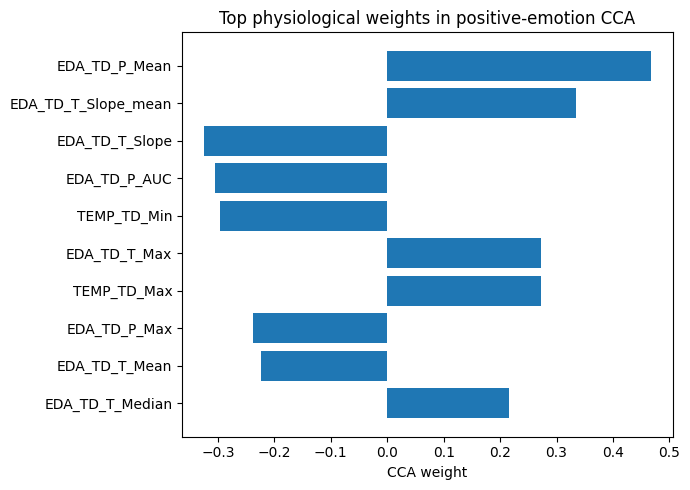

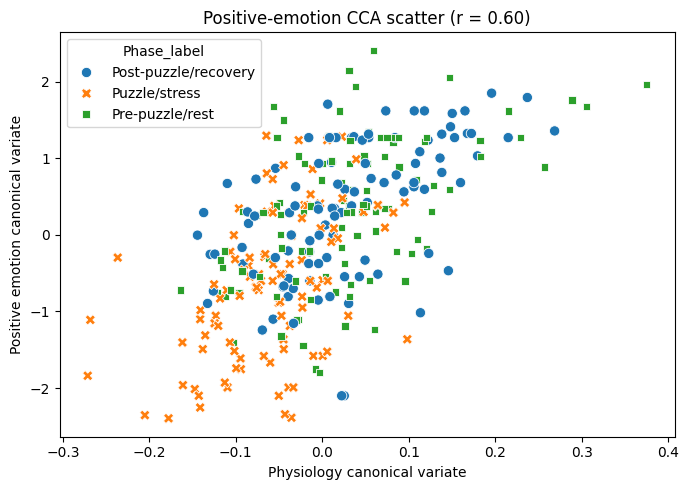

,feature,cca_weight,abs_weight
24,EDA_TD_P_Mean,0.466780,0.466780
46,EDA_TD_T_Slope_mean,0.333844,0.333844
47,EDA_TD_T_Slope,-0.323789,0.323789
29,EDA_TD_P_AUC,-0.305510,0.305510
15,TEMP_TD_Min,-0.295752,0.295752
40,EDA_TD_T_Max,0.273270,0.273270
16,TEMP_TD_Max,0.272444,0.272444
28,EDA_TD_P_Max,-0.237210,0.237210
36,EDA_TD_T_Mean,-0.223659,0.223659
37,EDA_TD_T_Median,0.215916,0.215916


,emotion,cca_weight,abs_weight
0,active,-0.751685,0.751685
2,attentive,-0.424735,0.424735
3,determined,0.383870,0.383870
1,alert,-0.314954,0.314954
4,inspired,0.089536,0.089536


In [13]:
X_all = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X))
Y_all = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(df[POSITIVE_COLS]))

cca = CCA(n_components=1, max_iter=500, tol=1e-4)

# CCA can occasionally raise a numerical convergence warning on small noisy datasets.
# The fitted scores are still used only for exploratory interpretation.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cca.fit(X_all, Y_all)
    X_score, Y_score = cca.transform(X_all, Y_all)

full_correlation = float(np.corrcoef(X_score[:, 0], Y_score[:, 0])[0, 1])
print(f"Full-data positive-emotion CCA correlation: {full_correlation:.3f}")

weights = pd.DataFrame({"feature": feature_cols, "cca_weight": cca.x_weights_[:, 0]})
weights["abs_weight"] = weights["cca_weight"].abs()
weights.sort_values("abs_weight", ascending=False).to_csv(
    RESULTS_DIR / "cca_positive_feature_weights.csv",
    index=False,
)

y_weights = pd.DataFrame({"emotion": POSITIVE_COLS, "cca_weight": cca.y_weights_[:, 0]})
y_weights["abs_weight"] = y_weights["cca_weight"].abs()
y_weights.sort_values("abs_weight", ascending=False).to_csv(
    RESULTS_DIR / "cca_positive_emotion_weights.csv",
    index=False,
)

top_weights = weights.sort_values("abs_weight", ascending=False).head(10).iloc[::-1]
plt.figure(figsize=(7, 5))
plt.barh(top_weights["feature"], top_weights["cca_weight"])
plt.xlabel("CCA weight")
plt.title("Top physiological weights in positive-emotion CCA")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cca_positive_top_features.png", dpi=250)
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_score[:, 0], y=Y_score[:, 0], hue=df["Phase_label"], style=df["Phase_label"], s=55)
plt.xlabel("Physiology canonical variate")
plt.ylabel("Positive emotion canonical variate")
plt.title(f"Positive-emotion CCA scatter (r = {full_correlation:.2f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cca_positive_scatter.png", dpi=250)
plt.show()

display(weights.sort_values("abs_weight", ascending=False).head(10))
display(y_weights.sort_values("abs_weight", ascending=False))

## 14. Factor handling: eta-squared heatmap

Metadata variables are not used as physiological input features, but they are important for interpretation. Eta-squared summarizes how much each factor is associated with each questionnaire variable.

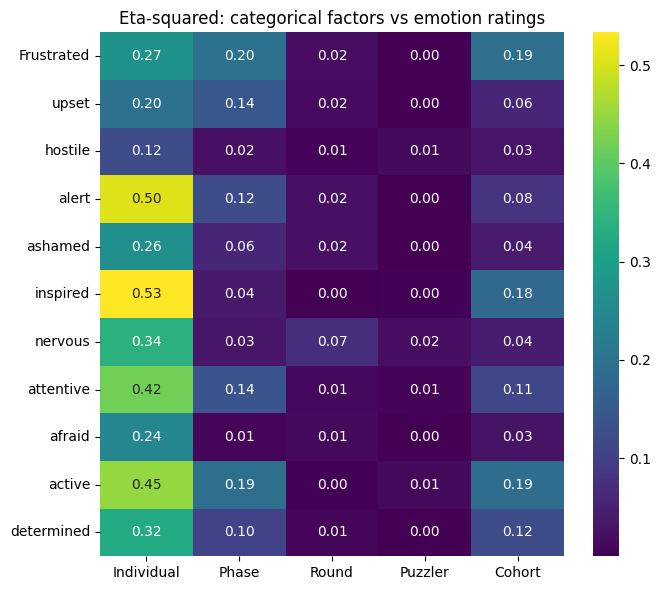

,Individual,Phase,Round,Puzzler,Cohort
Frustrated,0.269874,0.198357,0.017209,0.001905,0.192587
upset,0.201902,0.144131,0.015780,0.000973,0.057382
hostile,0.121720,0.022613,0.006142,0.013959,0.028418
alert,0.504676,0.122873,0.022309,0.000038,0.080124
ashamed,0.264813,0.058057,0.021712,0.000855,0.038383
inspired,0.533412,0.036972,0.000644,0.002980,0.177287
nervous,0.341294,0.029944,0.070870,0.019334,0.041933
attentive,0.418274,0.139503,0.011829,0.005316,0.114160
afraid,0.244936,0.007888,0.014276,0.000527,0.025801
active,0.445991,0.192825,0.002672,0.012940,0.188077


In [14]:
eta = pd.DataFrame(index=EMOTION_COLS, columns=FACTOR_COLS, dtype=float)

for emotion in EMOTION_COLS:
    for factor in FACTOR_COLS:
        eta.loc[emotion, factor] = eta_squared(df[factor], df[emotion])

eta.to_csv(RESULTS_DIR / "eta_squared_factor_effects.csv")

plt.figure(figsize=(7, 6))
sns.heatmap(eta.astype(float), annot=True, fmt=".2f", cmap="viridis")
plt.title("Eta-squared: categorical factors vs emotion ratings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eta_squared_heatmap.png", dpi=250)
plt.show()

eta

## 15. Save final summary

The summary file collects the most important numerical results used in the report.

In [15]:
summary = {
    "overview": overview,
    "missing_total": int(df.isna().sum().sum()),
    "pca_var_pc1": float(pca.explained_variance_ratio_[0]),
    "pca_var_pc2": float(pca.explained_variance_ratio_[1]),
    "pca_var_first5": float(np.sum(pca.explained_variance_ratio_[:5])),
    "cluster_pca_ari": float(cluster_results.loc[0, "ARI_vs_Phase"]),
    "phase_random_bal_acc_mean": float(random_scores.mean()),
    "phase_group_bal_acc_mean": float(group_scores.mean()),
    "cca_pos_random_mean": float(
        cca_results.query("emotion_set == 'Positive emotions' and validation == 'Random 5-fold'")[
            "mean_canonical_corr"
        ].iloc[0]
    ),
    "cca_pos_group_mean": float(
        cca_results.query("emotion_set == 'Positive emotions' and validation == 'Subject-aware GroupKFold'")[
            "mean_canonical_corr"
        ].iloc[0]
    ),
    "cca_neg_group_mean": float(
        cca_results.query("emotion_set == 'Negative emotions' and validation == 'Subject-aware GroupKFold'")[
            "mean_canonical_corr"
        ].iloc[0]
    ),
    "cca_all_group_mean": float(
        cca_results.query("emotion_set == 'All emotions incl. frustration' and validation == 'Subject-aware GroupKFold'")[
            "mean_canonical_corr"
        ].iloc[0]
    ),
    "cca_pos_full_corr": full_correlation,
    "top_cca_features": weights.sort_values("abs_weight", ascending=False).head(5)["feature"].tolist(),
}

with open(RESULTS_DIR / "summary.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

print(json.dumps(summary, indent=2))

{
  "overview": {
    "n_rows": 312,
    "n_columns": 68,
    "n_individuals": 26,
    "n_phases": 3,
    "n_rounds": 4,
    "n_physio_features": 51,
    "n_emotion_variables": 11
  },
  "missing_total": 9,
  "pca_var_pc1": 0.27810238580487595,
  "pca_var_pc2": 0.10048215802575852,
  "pca_var_first5": 0.584154162283096,
  "cluster_pca_ari": -0.0024606863327978922,
  "phase_random_bal_acc_mean": 0.45904761904761904,
  "phase_group_bal_acc_mean": 0.4583333333333333,
  "cca_pos_random_mean": 0.24264121723411908,
  "cca_pos_group_mean": 0.06885507530170697,
  "cca_neg_group_mean": -0.012349453196788351,
  "cca_all_group_mean": 0.17876299324577527,
  "cca_pos_full_corr": 0.6034254822620292,
  "top_cca_features": [
    "EDA_TD_P_Mean",
    "EDA_TD_T_Slope_mean",
    "EDA_TD_T_Slope",
    "EDA_TD_P_AUC",
    "TEMP_TD_Min"
  ]
}


## 16. Main interpretation

The main validation results are intentionally interpreted conservatively. PCA gives a useful low-dimensional summary of the physiological features, but unsupervised PCA clusters do not strongly align with experimental phase. The phase-classification diagnostic is only moderately above chance under subject-aware validation, and the CCA relationships become weaker when validation is performed by `Individual` groups.

This supports the central conclusion of the analysis: the extracted wearable biosignal features contain some physiological and emotion-related structure, but the signal is weak and strongly affected by individual baselines. Therefore, subject-aware validation is necessary to avoid over-interpreting patterns that may not generalize to unseen participants.

## 17. Main generated files

After running the notebook, the updated figures and result tables are available in the `figures/` and `results/` folders. The most important figures are displayed below.

pca_explained_variance.png


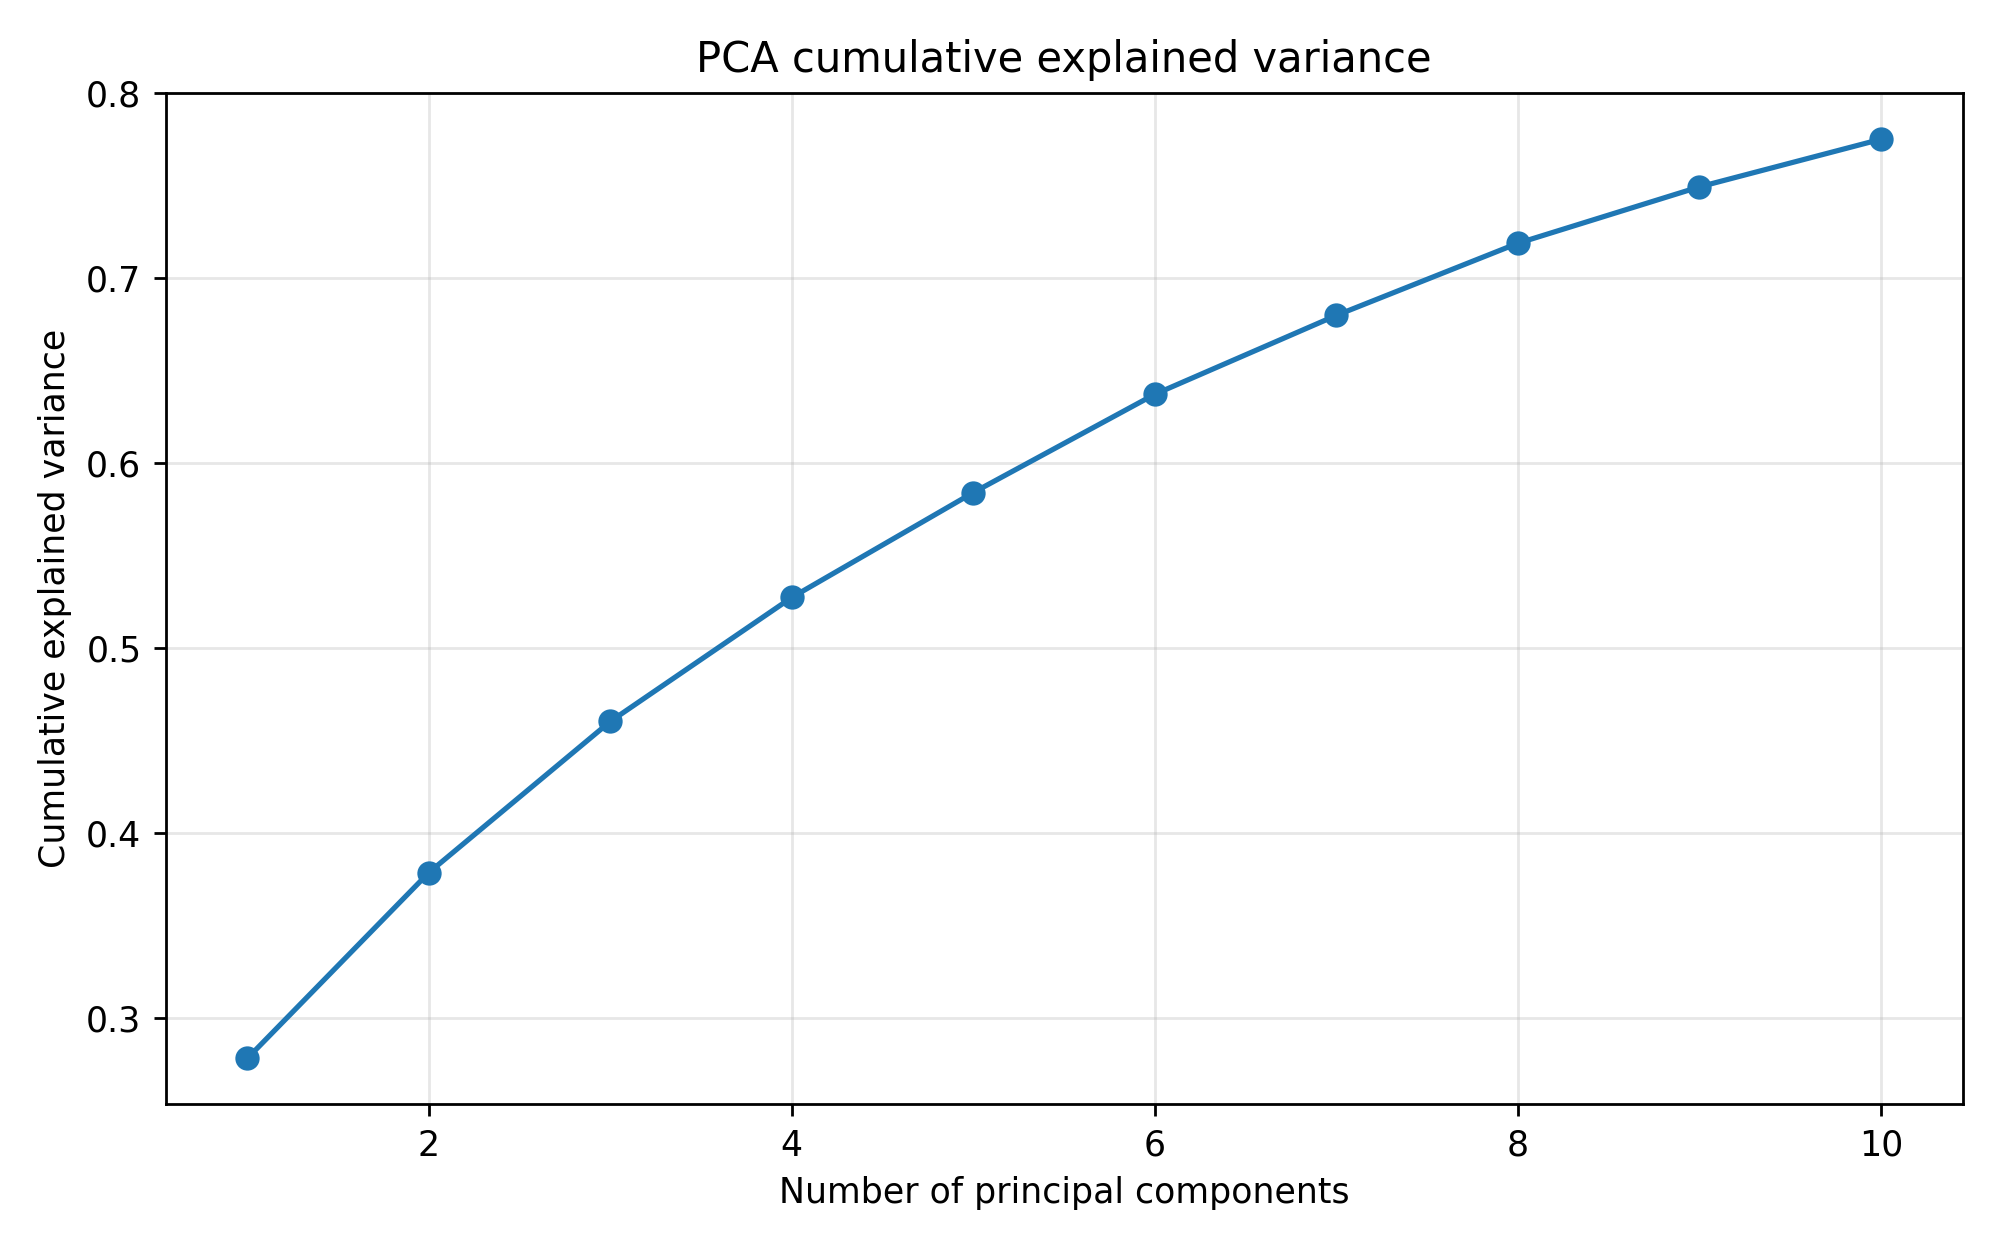

pca_by_phase.png


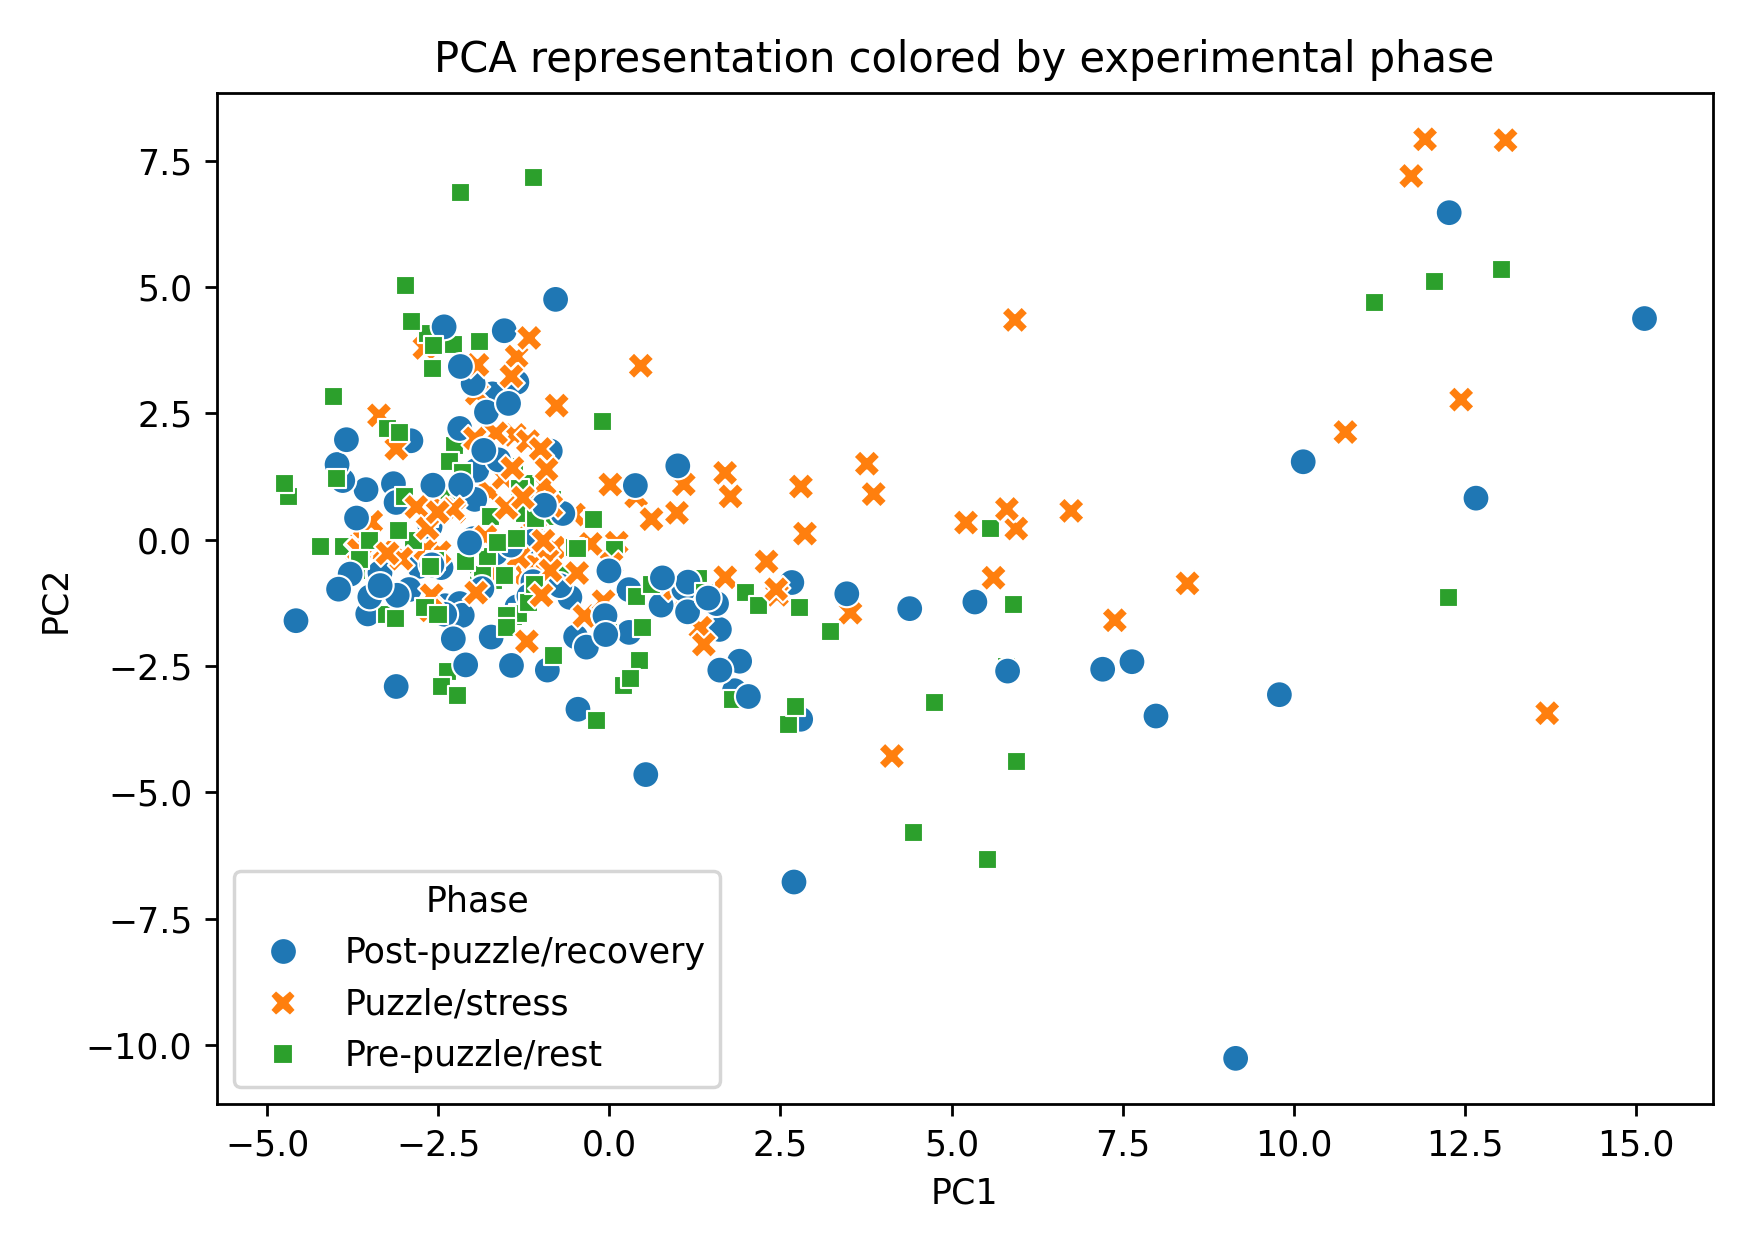

pca_by_individual.png


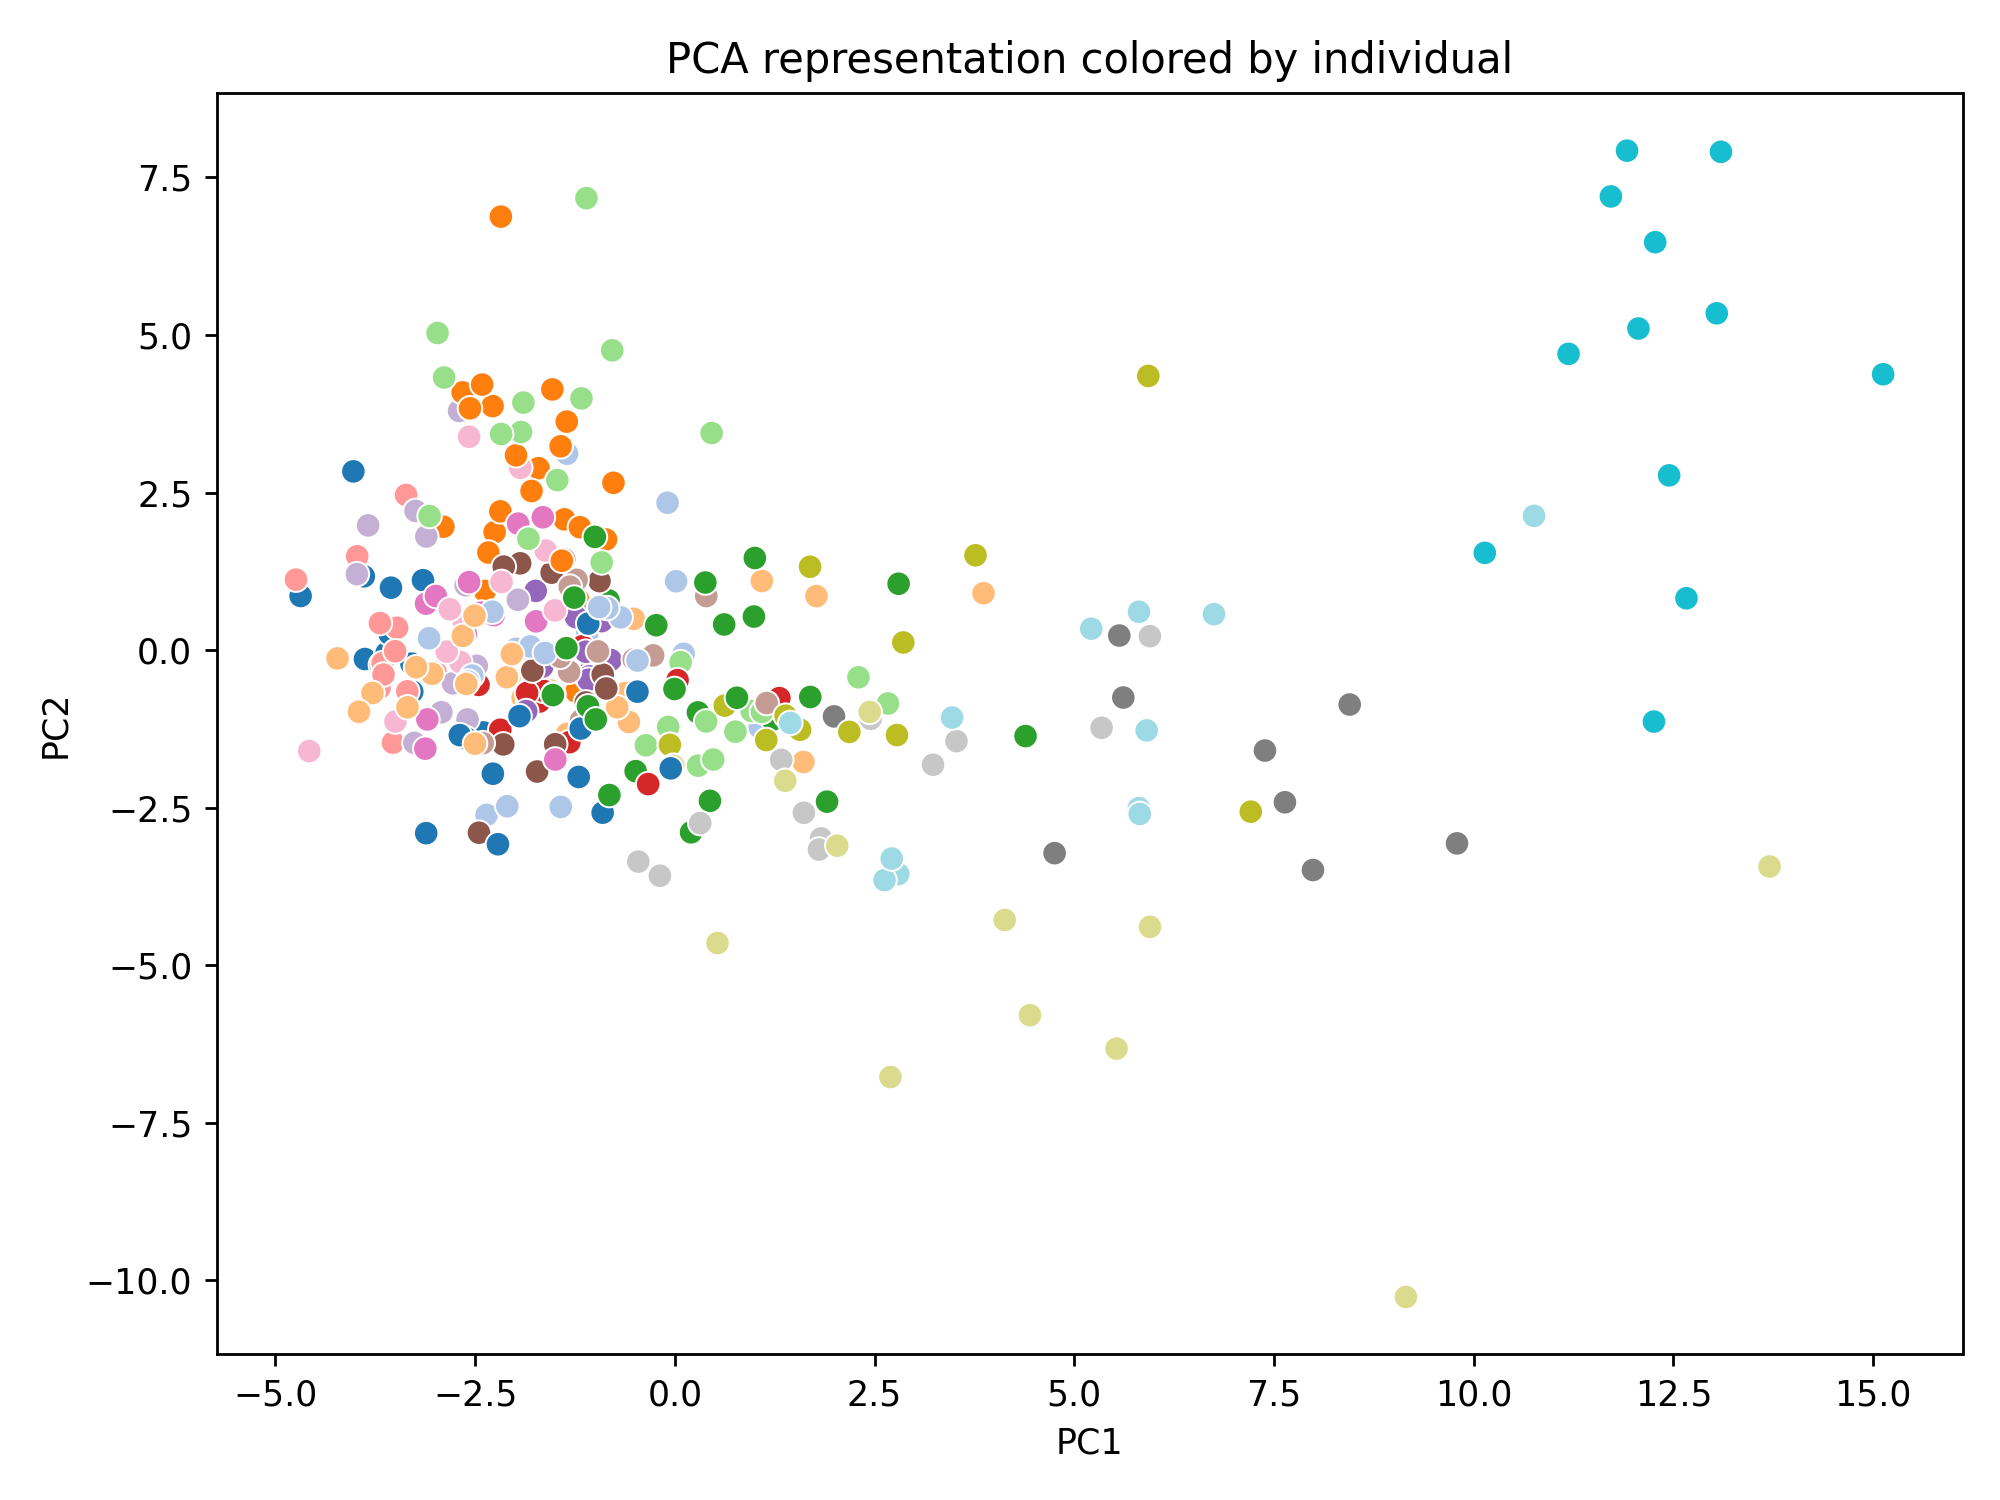

cca_positive_scatter.png


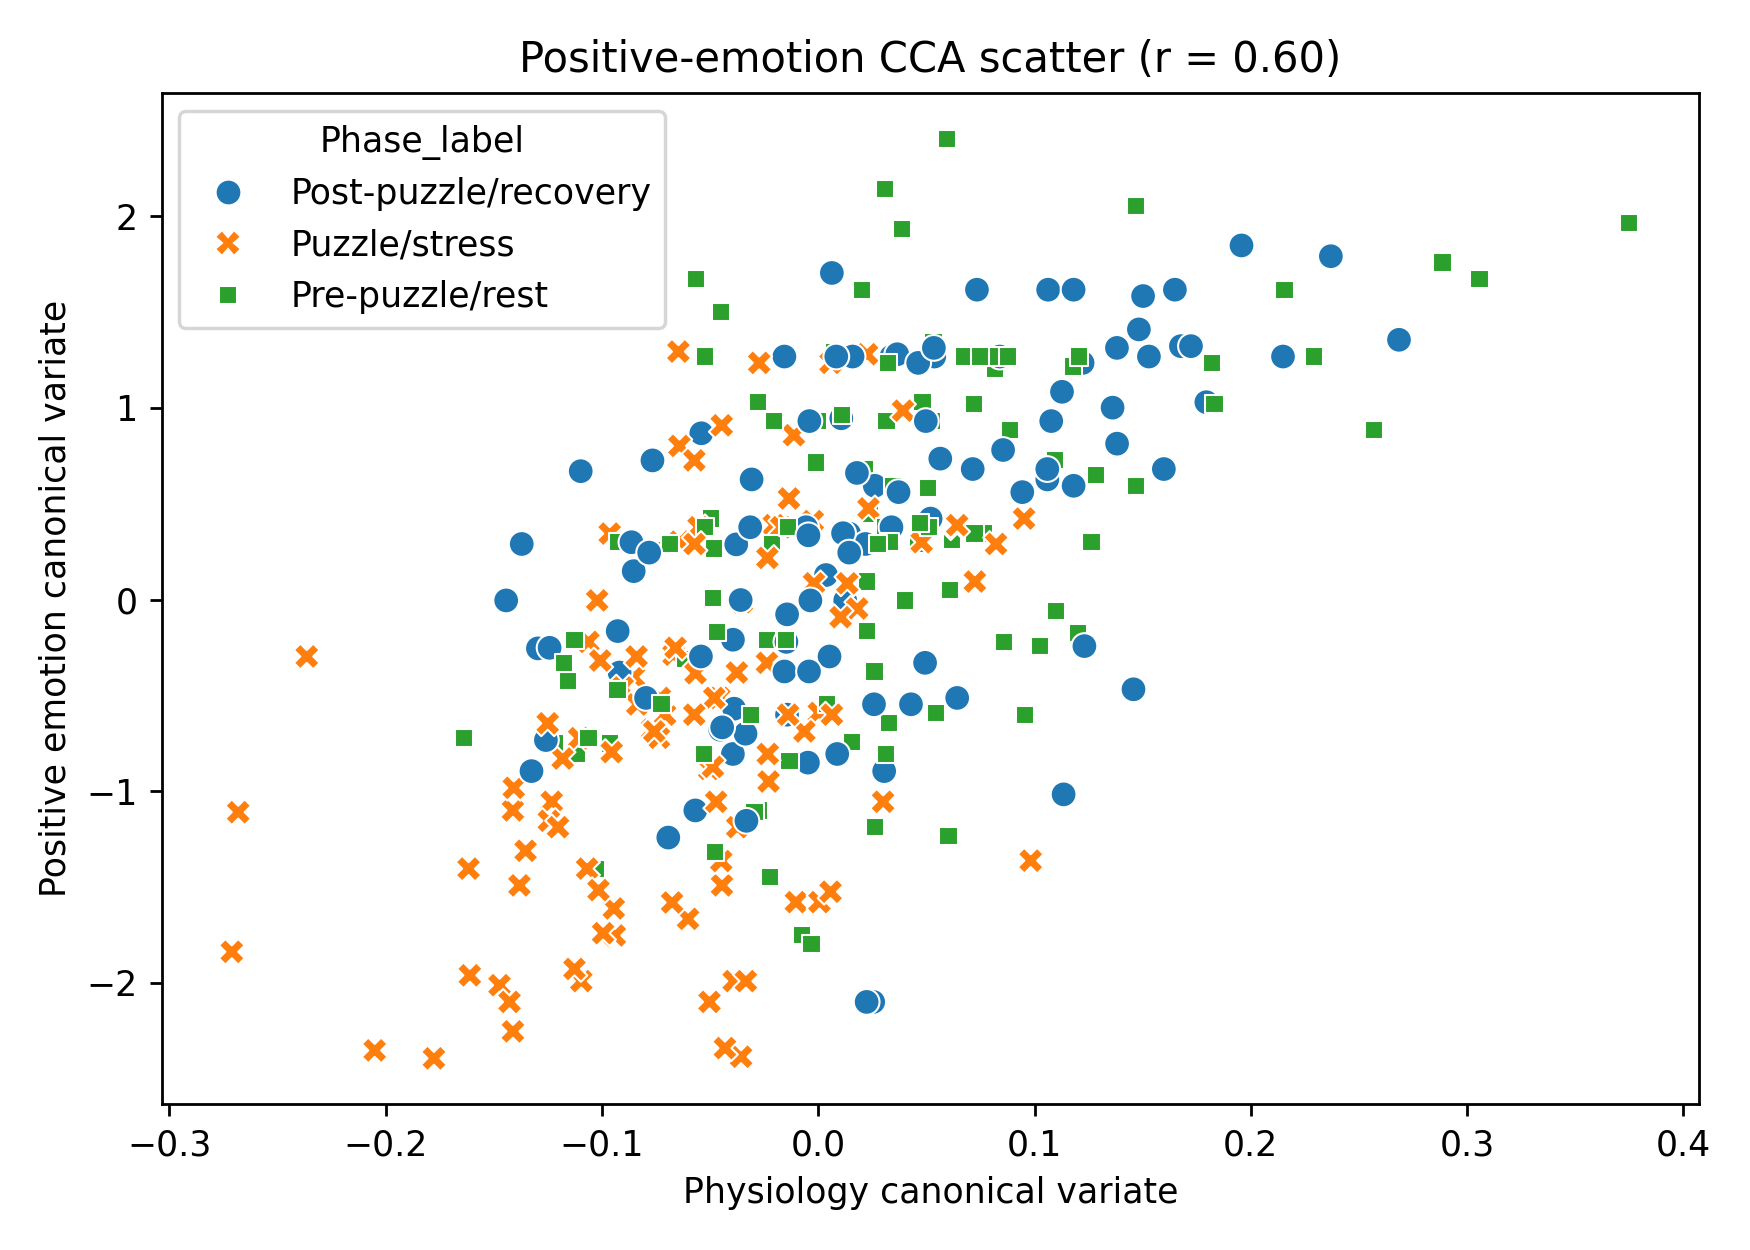

cca_positive_top_features.png


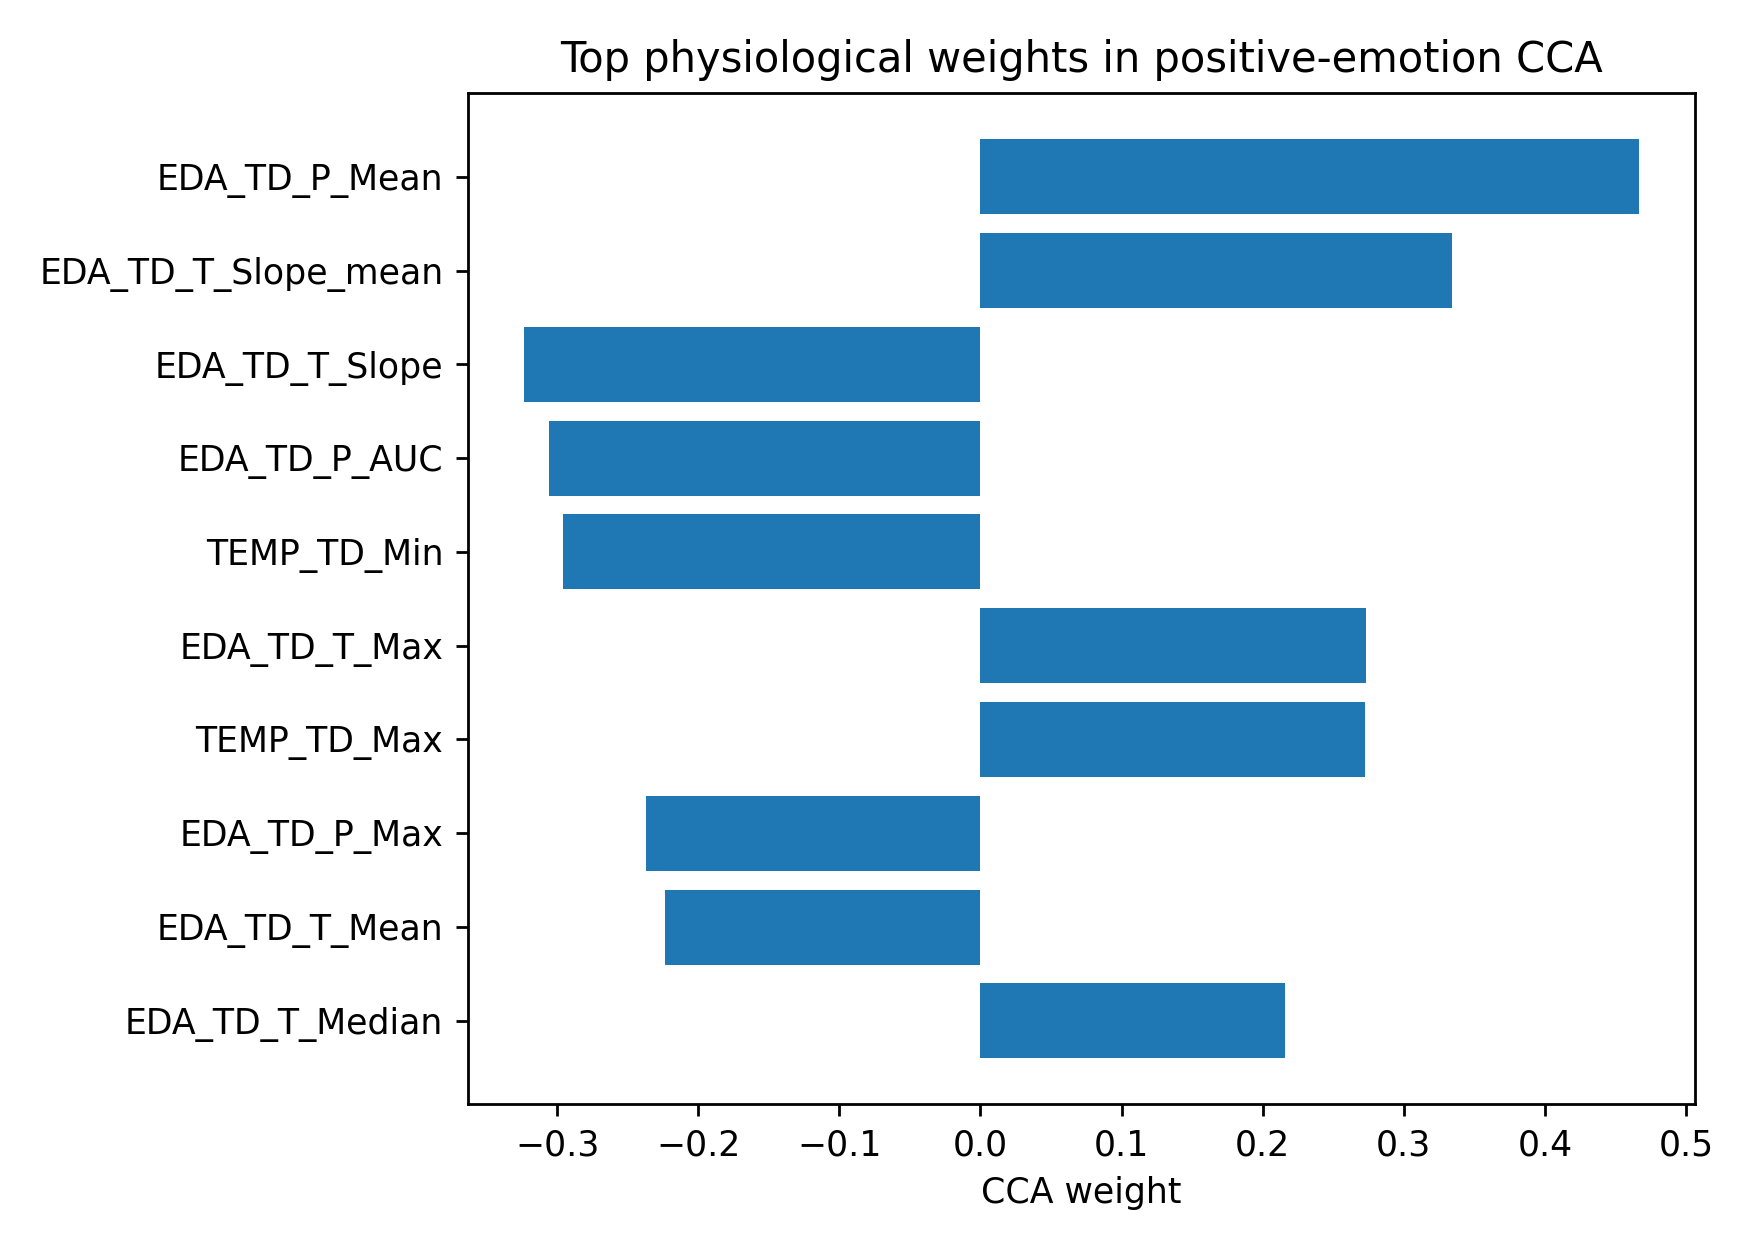

eta_squared_heatmap.png


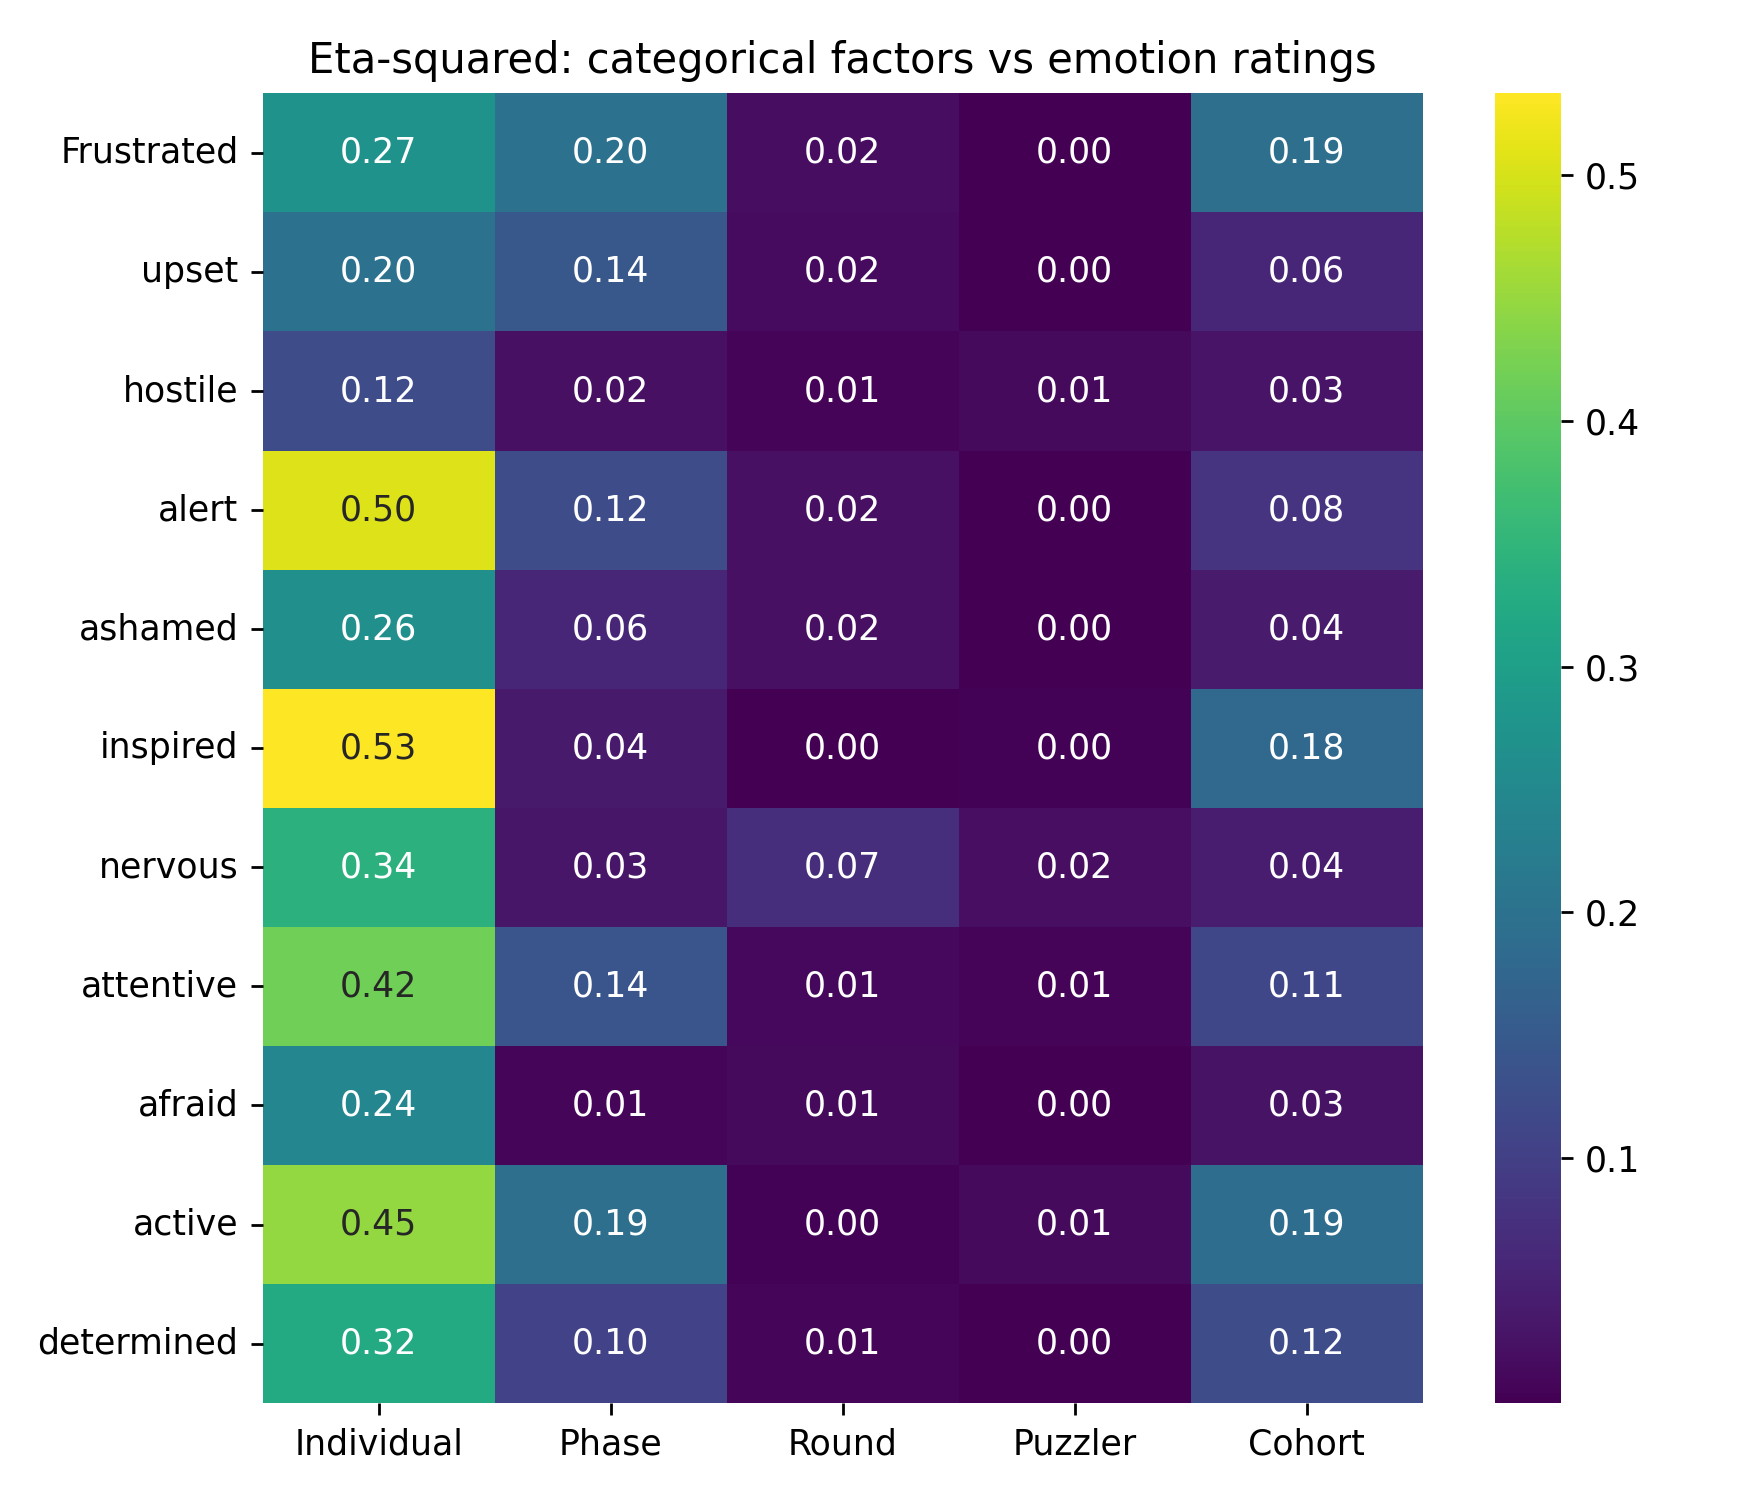

In [16]:
for fig_name in [
    "pca_explained_variance.png",
    "pca_by_phase.png",
    "pca_by_individual.png",
    "cca_positive_scatter.png",
    "cca_positive_top_features.png",
    "eta_squared_heatmap.png",
]:
    print(fig_name)
    display(Image(filename=str(FIGURES_DIR / fig_name)))

In [17]:
expected_files = [
    FIGURES_DIR / "emotion_boxplot.png",
    FIGURES_DIR / "emotion_correlation_heatmap.png",
    FIGURES_DIR / "pca_explained_variance.png",
    FIGURES_DIR / "pca_by_phase.png",
    FIGURES_DIR / "pca_by_individual.png",
    FIGURES_DIR / "pca_top_loadings_pc1.png",
    FIGURES_DIR / "cca_positive_scatter.png",
    FIGURES_DIR / "cca_positive_top_features.png",
    FIGURES_DIR / "eta_squared_heatmap.png",
    RESULTS_DIR / "dataset_overview.csv",
    RESULTS_DIR / "missing_values.csv",
    RESULTS_DIR / "emotion_descriptive_statistics.csv",
    RESULTS_DIR / "pca_explained_variance.csv",
    RESULTS_DIR / "clustering_phase_alignment.csv",
    RESULTS_DIR / "phase_classification_validation.csv",
    RESULTS_DIR / "cca_validation_results.csv",
    RESULTS_DIR / "summary.json",
]

missing_outputs = [str(path) for path in expected_files if not path.exists()]
if missing_outputs:
    message = "Some expected output files are missing:\n" + "\n".join(missing_outputs)
    raise FileNotFoundError(message)

print("Final sanity check passed.")
print(f"Generated {len(expected_files)} expected output files.")
print("Notebook results are ready to be synchronized with the report.")

Final sanity check passed.
Generated 17 expected output files.
Notebook results are ready to be synchronized with the report.
